In [2]:
import pandas as pd
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import joblib # Para salvar os normalizadores

In [3]:
def create_delta_data(local_data):
    OriginalData = pd.read_csv(local_data)
    OriginalData.index = (np.arange(0, len(OriginalData), 1).astype(float) * 0.07).round(5)
    OriginalData = OriginalData.drop(columns=["x(Wd,We)", "y(Wd,We)", "tempo"])
    theta = OriginalData["theta(Wd,We)"].to_numpy()
    theta_0 = theta[:-1]
    theta_1 = theta[1:]
    delta_theta = (theta_1 - theta_0) / 0.07
    wd_alinhado = OriginalData['Wd'].iloc[:-1]  
    we_alinhado = OriginalData['We'].iloc[:-1] 
    wd_true_alinhado = OriginalData['Wd_true'].iloc[:-1]
    we_true_alinhado = OriginalData['We_true'].iloc[:-1]
    df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'delta_theta': delta_theta,
        'Wd_true': wd_true_alinhado,
        'We_true': we_true_alinhado
    })
    print(df_new.head())
    print("Shape do novo_df:", df_new.shape)
    return df_new
TrainData = create_delta_data("./Dados/DataSmoothSpline1.csv")
TestData = create_delta_data("./Dados/DataSmoothSpline3.csv")
ValData = create_delta_data("./Dados/DataSmoothSpline2.csv")


            Wd        We  delta_theta   Wd_true   We_true
0.00  2.046979  2.067159     0.004965  0.163271  0.093873
0.07  2.058519  2.079836     0.004959  0.242458  0.175944
0.14  2.069982  2.092437     0.004942  0.321637  0.258010
0.21  2.081302  2.104891     0.004909  0.400792  0.340061
0.28  2.092419  2.117138     0.004853  0.479896  0.422075
Shape do novo_df: (2145, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  2.250967  2.289211     0.008868  0.204149  0.077678
0.07  2.246293  2.286558     0.008856  0.283600  0.162385
0.14  2.241624  2.283906     0.008824  0.363042  0.247087
0.21  2.236964  2.281260     0.008762  0.442455  0.331776
0.28  2.232324  2.278624     0.008659  0.521806  0.416432
Shape do novo_df: (2026, 5)
            Wd        We  delta_theta   Wd_true   We_true
0.00  1.866241  1.950911     0.007093  0.118729 -0.110797
0.07  1.870389  1.957288     0.007070  0.187222 -0.030969
0.14  1.874468  1.963593     0.007006  0.255708  0.048863
0.21  1.878425  

In [4]:
# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "delta_theta"
RESTRICTIONS = ["Wd_true", "We_true"]


Restrictions_data = TrainData[RESTRICTIONS].to_numpy()

print("\nShape de Restrictions_data:", Restrictions_data.shape)
print("Primeiras linhas de Restrictions_data:\n", Restrictions_data[:5])

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()


x_scaler = MinMaxScaler(feature_range=(-1, 1))
y_scaler = MinMaxScaler(feature_range=(-1, 1))

print("\nAjustando os normalizadores (scalers) com os dados de treino...")
x_scaler.fit(train_x)
y_scaler.fit(train_y)

joblib.dump(x_scaler, 'x_scaler.gz')
joblib.dump(y_scaler, 'y_scaler.gz')
print("Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'")

# AGORA, TRANSFORME TODOS OS CONJUNTOS DE DADOS com os scalers já ajustados
train_x_norm = x_scaler.transform(train_x)
train_y_norm = y_scaler.transform(train_y)

x_val_norm = x_scaler.transform(x_val)
y_val_norm = y_scaler.transform(y_val)

x_test_norm = x_scaler.transform(x_test)
y_test_norm = y_scaler.transform(y_test)

restric_norm = x_scaler.transform(Restrictions_data)
print("\nShape de Restrictions_data normalizado:", restric_norm.shape)

print("\nShape de X_train depois da normalização:", train_x_norm.shape)
print("Primeiras linhas de X_train normalizado:\n", train_x_norm[:5])
print("\nPrimeiras linhas de y_train normalizado:\n", train_y_norm[:5])



Shape de Restrictions_data: (2145, 2)
Primeiras linhas de Restrictions_data:
 [[0.16327083 0.0938734 ]
 [0.24245778 0.17594412]
 [0.32163697 0.25801016]
 [0.40079243 0.34006069]
 [0.47989594 0.42207508]]
(2145, 2)

Ajustando os normalizadores (scalers) com os dados de treino...
Normalizadores salvos como 'x_scaler.gz' e 'y_scaler.gz'

Shape de Restrictions_data normalizado: (2145, 2)

Shape de X_train depois da normalização: (2145, 2)
Primeiras linhas de X_train normalizado:
 [[0.84617662 0.86253703]
 [0.85097515 0.86788632]
 [0.85574195 0.87320305]
 [0.86044886 0.87845795]
 [0.86507184 0.8836256 ]]

Primeiras linhas de y_train normalizado:
 [[0.07529811]
 [0.07527054]
 [0.07519498]
 [0.07504621]
 [0.07479823]]


In [5]:
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       y_scaler,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    #restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            #y_k   = y_pred[1:]
            #y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:, 0]   # Wd
            x2_km1 = restrictions_data[:, 1]   # We
            #x1_km1 = train_x[:, 0]  # Wd
            #x2_km1 = train_x[:, 1]  # We
            # calcula derivada aproximada
            #dy_dt = (y_k - y_km1) / Ts
            phys_real  = ((R / L) * (x1_km1 - x2_km1)) 

            phys_real = phys_real.reshape((-1, 1))  # shape [N-1, 1]
            phys_norm = y_scaler.transform(phys_real)
            MSE_f = tf.reduce_mean(tf.square(y_pred - phys_norm))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % 500 == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4g}, MSE_d={MSE_d.numpy():.4g}, MSE_f={MSE_f.numpy():.4g}, Val MSE={val_d.numpy():.4g}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }
    if plot:
        for split, m in metrics.items():
            print(f"\n{split} Metrics:")
            for k, v in m.items():
                print(f"  {k}: {v:.4g}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        #print(model.trainable_variables)

    return metrics

In [6]:
def create_sequences(input_data, target_data, timesteps):
    """
    Cria sequências de dados para treinamento de RNN.

    Args:
        input_data (np.array): Dados de entrada (X), formato (samples, features).
        target_data (np.array): Dados de saída (Y), formato (samples, target_features).
        timesteps (int): O número de passos de tempo passados a serem considerados.

    Returns:
        X_seq (np.array): Dados de entrada sequenciais, formato (N, timesteps, features).
        Y_seq (np.array): Dados de saída correspondentes, formato (N, target_features).
    """
    X_seq, Y_seq = [], []
    
    # Itera sobre os dados, começando após o número de timesteps
    for i in range(timesteps, len(input_data)):
        # A sequência de entrada (X_seq) é a janela de dados de i-timesteps até i
        X_seq.append(input_data[i-timesteps:i])
        
        # O alvo (Y_seq) é o valor de saída no passo de tempo atual 'i'
        Y_seq.append(target_data[i])
    
    return np.array(X_seq), np.array(Y_seq)

FEATURES = 2 # Wd e We

c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0.5, λ2=0.5
Epoch 1: Loss=1.14, MSE_d=1.14, MSE_f=1.14, Val MSE=0.9516
Epoch 500: Loss=0.06109, MSE_d=0.05633, MSE_f=0.06585, Val MSE=0.09904
Epoch 1000: Loss=0.05549, MSE_d=0.05058, MSE_f=0.0604, Val MSE=0.08943
Epoch 1500: Loss=0.04315, MSE_d=0.03819, MSE_f=0.04812, Val MSE=0.0687
Epoch 2000: Loss=0.02441, MSE_d=0.02088, MSE_f=0.02795, Val MSE=0.03824
Epoch 2500: Loss=0.01133, MSE_d=0.009568, MSE_f=0.01309, Val MSE=0.02112
Epoch 3000: Loss=0.007553, MSE_d=0.006175, MSE_f=0.008932, Val MSE=0.0162
Epoch 3500: Loss=0.006379, MSE_d=0.005207, MSE_f=0.007551, Val MSE=0.01571
Epoch 4000: Loss=0.005679, MSE_d=0.004617, MSE_f=0.006742, Val MSE=0.0155
Early stopping na época 4105

Training Metrics:
  R2: 0.9329
  MSE: 0.005181
  RMSE: 0.07198
  MAPE: 3.075

Validation Metrics:
  R2: 0.8917
  MSE: 0.01511
  RMSE: 0.1229
  MAPE: 2.105

Test Metrics:
  R2: 0.7055
  MSE: 0.01601
  RMSE: 0.1265
  MAPE: 1.245
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
42/42 ━━

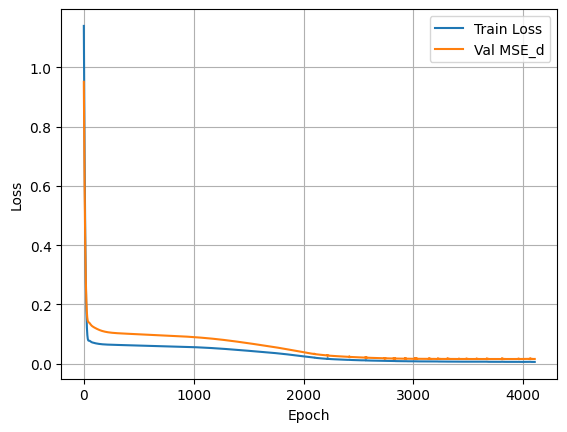

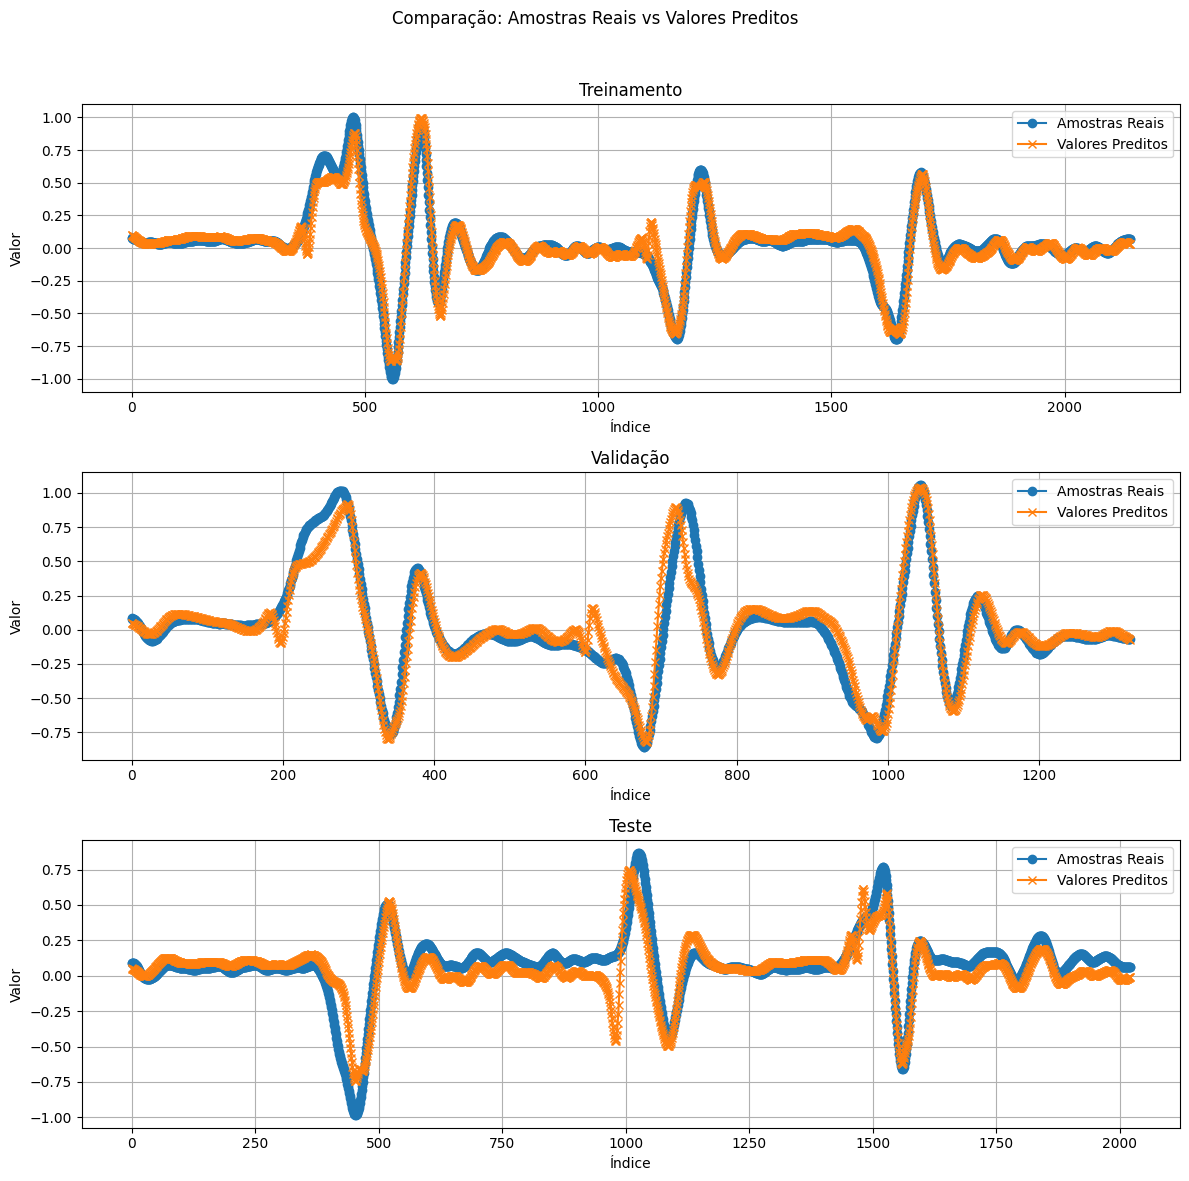

{'Training': {'R2': 0.9328516125679016,
  'MSE': 0.005180514417588711,
  'RMSE': 0.07197579049644895,
  'MAPE': 3.0748932361602783},
 'Validation': {'R2': 0.8917331099510193,
  'MSE': 0.015114939771592617,
  'RMSE': 0.12294283131436586,
  'MAPE': 2.104508399963379},
 'Test': {'R2': 0.705543041229248,
  'MSE': 0.016013693064451218,
  'RMSE': 0.1265452214208471,
  'MAPE': 1.2452383041381836}}

In [9]:
TIME_STEPS = 4 # Usando apenas o passo atual para o modelo RNN
model_pirrn = keras.models.Sequential([
    keras.layers.SimpleRNN(15, return_sequences=False, input_shape=[TIME_STEPS, FEATURES], kernel_regularizer= keras.regularizers.l2(0)),
    keras.layers.Dense(1, use_bias= False)
])
train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, TIME_STEPS)
x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, TIME_STEPS)
x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, TIME_STEPS)
custom_train_model_with_es_physics(model_pirrn,
                                       train_x = train_x_seq, train_y = train_y_seq,
                                       x_val = x_val_seq, y_val = y_val_seq,
                                       x_test = x_test_seq, y_test = y_test_seq,
                                       restrictions_data = Restrictions_data[:-TIME_STEPS,:],
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_scaler= y_scaler,
                                       lambda1=0.5, lambda2=0.5,
                                       epochs = 15000, patience=300,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True)
#MSE TESTE 0.02434 

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE entre Theta Original e Reconstruído: 0.5014


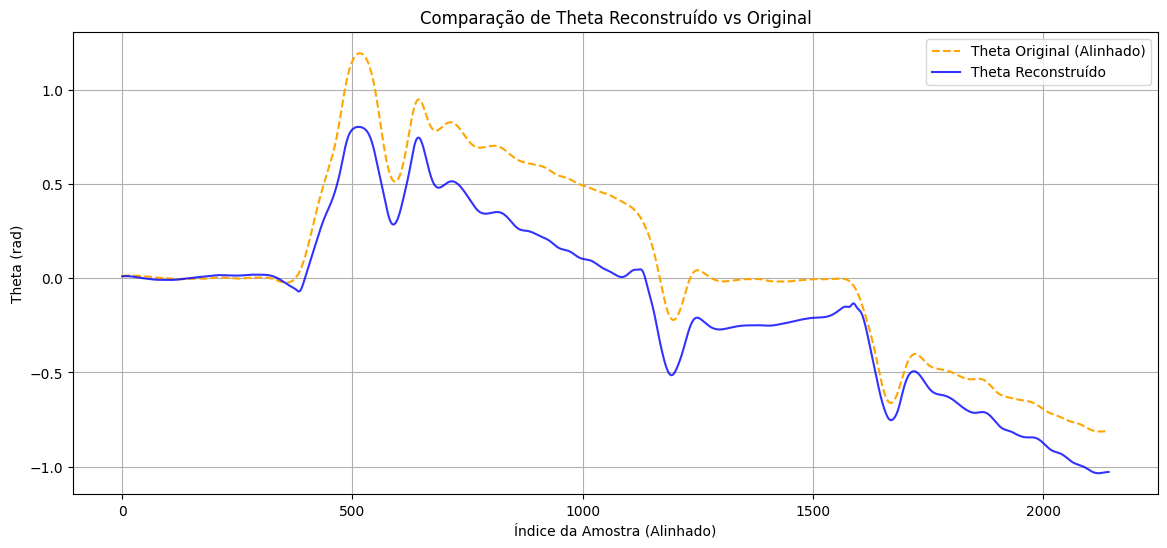

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
MSE entre Theta Original e Reconstruído: 0.4116


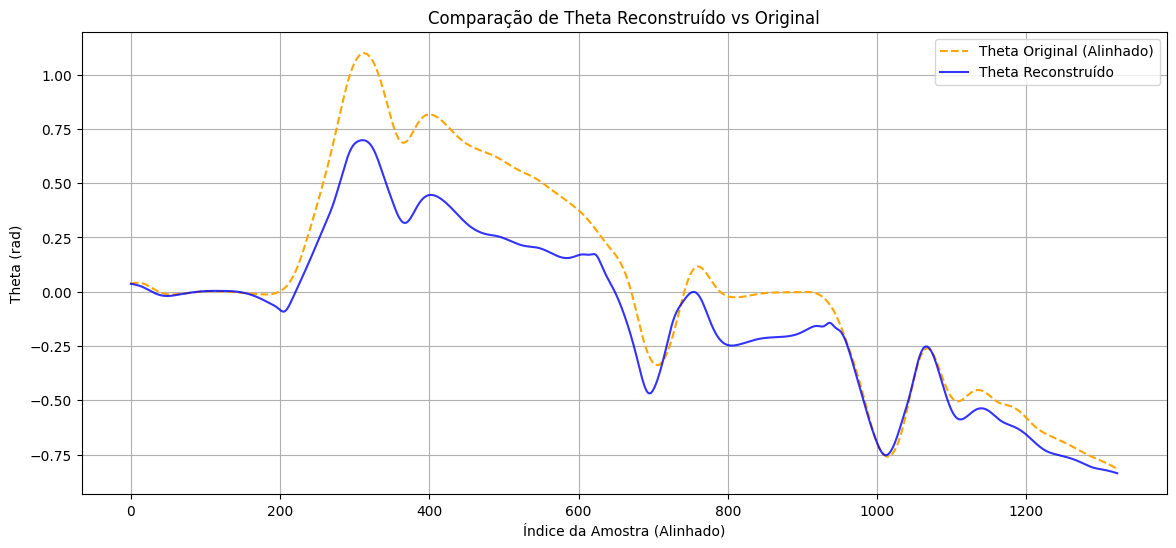

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE entre Theta Original e Reconstruído: 0.2556


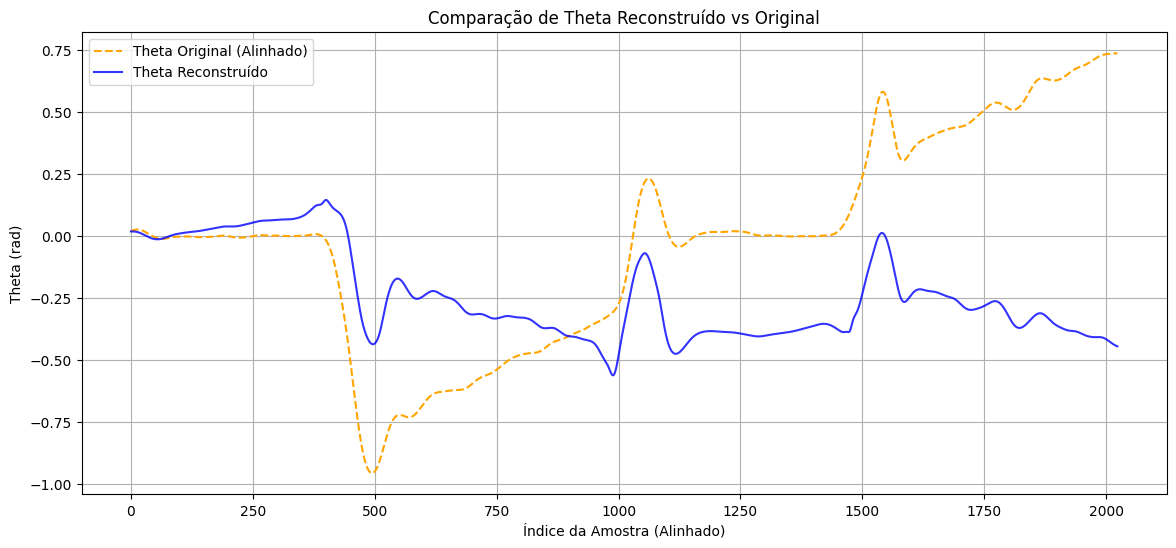

0.25561524123244644

In [15]:
def Recontruir_Theta(model, inputs_norm, local_data_original, y_scaler):
    """
    Reconstrói o sinal de Theta a partir da previsão de sua derivada,
    e calcula o MSE de forma correta e alinhada.
    """

    Y_norm_pred = model.predict(inputs_norm)
    Y_pred_real = y_scaler.inverse_transform(Y_norm_pred) # Derivada na escala real

    DataOrigi = pd.read_csv(local_data_original)
    Theta_true = DataOrigi["theta(Wd,We)"].to_numpy()
    theta_reconstruido = np.zeros_like(Y_pred_real)
    theta_reconstruido[0] = Theta_true[0] + Y_pred_real[0] * 0.07


    for i in range(1, len(Y_pred_real)):
        # Fórmula da integração de Euler: y(t) = y(t-1) + y'(t) * dt
        theta_reconstruido[i] = theta_reconstruido[i-1] + Y_pred_real[i] * 0.07
    

    offset = len(Theta_true) - len(theta_reconstruido)
    Theta_true_alinhado = Theta_true[offset:]

    # O cálculo do MSE agora é feito entre dois vetores do mesmo tamanho.
    mse = np.mean(np.square(Theta_true_alinhado - theta_reconstruido))
    
    print(f"MSE entre Theta Original e Reconstruído: {mse:.4g}")

    # Plotando os dados alinhados
    plt.figure(figsize=(14, 6))
    plt.plot(Theta_true_alinhado, label='Theta Original (Alinhado)', color='orange', linestyle='--')
    plt.plot(theta_reconstruido, label='Theta Reconstruído', color='blue', alpha=0.8)
    plt.xlabel('Índice da Amostra (Alinhado)')
    plt.ylabel('Theta (rad)')
    plt.title('Comparação de Theta Reconstruído vs Original')
    plt.legend()
    plt.grid(True)
    plt.show() # Adicionado para exibir o gráfico
    
    return mse



Recontruir_Theta(model_pirrn, train_x_seq, "./Dados/DataSmoothSpline1.csv", y_scaler)
Recontruir_Theta(model_pirrn, x_val_seq, "./Dados/DataSmoothSpline2.csv", y_scaler)
Recontruir_Theta(model_pirrn, x_test_seq, "./Dados/DataSmoothSpline3.csv", y_scaler)

In [45]:
def AvalModel(model,train_x, train_y,x_val, y_val,x_test, y_test,plot = True):
    """
    Avalia o modelo em termos de R2, MSE, RMSE e MAPE.
    
    """
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)


    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred

    metrics = {
        'Train': {
            'R2': r2_score(train_y_np, train_pred_np),
            'MSE': mean_squared_error(train_y_np, train_pred_np),
            'RMSE': root_mean_squared_error(train_y_np, train_pred_np),
            'MAPE': mean_absolute_percentage_error(train_y_np,train_pred_np)
        },
        'Validation': {
            'R2': r2_score(y_val_np, val_pred_np),
            'MSE': mean_squared_error(y_val_np, val_pred_np),
            'RMSE': root_mean_squared_error(y_val_np, val_pred_np),
            'MAPE': mean_absolute_percentage_error(y_val_np, val_pred_np)
        },
        'Test': {
            'R2': r2_score(y_test_np, test_pred_np),
            'MSE': mean_squared_error(y_test_np, test_pred_np),
            'RMSE': root_mean_squared_error(y_test_np, test_pred_np),
            'MAPE': mean_absolute_percentage_error(y_test_np, test_pred_np)
        }
    }

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        axs[i].grid(True) 


    return metrics


In [ ]:
def CreateModel(input_size = 2, output_size = 1, units = 10, time_steps = 2, n_seed = [32, 67, 90, 546], lam_1 = 1.0, lam_2 = 0.0, lr = 0.01):
    """
    Cria um modelo Sequential com uma camada RNN e uma camada Dense.

    """
    train_x_seq, train_y_seq = create_sequences(train_x_norm, train_y_norm, time_steps)
    x_val_seq, y_val_seq = create_sequences(x_val_norm, y_val_norm, time_steps)
    x_test_seq, y_test_seq = create_sequences(x_test_norm, y_test_norm, time_steps)
    
    model = keras.models.Sequential([
        keras.layers.SimpleRNN(units, return_sequences=False, input_shape=[time_steps, input_size],),
        keras.layers.Dense(output_size)
    ])

    metrics = custom_train_model_with_es_physics(model_pirrn,
                                       train_x = train_x_seq, train_y = train_y_seq,
                                       x_val = x_val_seq, y_val = y_val_seq,
                                       x_test = x_test_seq, y_test = y_test_seq,
                                       restrictions_data = Restrictions_data[:-2,:],
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       y_scaler= y_scaler,
                                       lambda1= lam_1, lambda2=lam_2,
                                       epochs = 10000, patience=300,
                                       min_delta=0, plot=False,
                                       learning_rate= lr, use_early_stopping=True)

    
    return model, metrics


def Generate_Random_Models(units=10, time_steps=2, lam_1=1.0, lam_2=0.0):
    """
    Treina vários modelos com seeds e learning rates aleatórios,
    retornando o melhor modelo encontrado com base no MSE de teste.
    """
    best_test_mse = float('inf')
    best_test_r2 = None
    best_model = None
    best_seed = None
    best_lr = None
    best_metrics = None

    for i in range(10):
        # Seed aleatória
        np_seed = np.random.randint(1, 10000)

        # Learning rate aleatório (exemplo: entre 1e-4 e 1e-2)
        lr_rand = 10 ** np.random.uniform(-4, -2)

        print(f"Modelo {i+1}: unidades = {units}, seed = {np_seed}, lr = {lr_rand:.5f}")

        # Criação e treino do modelo
        model, metrics = CreateModel(
            units=units,
            time_steps=time_steps,
            lam_1=lam_1,
            lam_2=lam_2,
            n_seed=np_seed,
            lr=lr_rand
        )

        # Métricas do teste
        test_mse = metrics['Test']['MSE']
        if test_mse < best_test_mse:
            best_test_mse = test_mse
            best_model = model
            best_seed = np_seed
            best_lr = lr_rand
            best_test_r2 = metrics['Test']['R2']
            best_metrics = metrics
            print(f"Novo melhor modelo: MSE = {best_test_mse:.4g}, R2 = {best_test_r2:.4g}, lr = {best_lr:.5f}")

    print(f"\nMelhor modelo final: MSE = {best_test_mse:.4g}, R2 = {best_test_r2:.4g}, unidades = {units}, seed = {best_seed}, lr = {best_lr:.5f}")
    return best_model, best_metrics

model_5, metrics_5   =   Generate_Random_Models(units=5)
model_10, metrics_10 = Generate_Random_Models(units=10)
model_15, metrics_15 = Generate_Random_Models(units=15)
model_20, metrics_20 = Generate_Random_Models(units=20)
model_25, metrics_25 = Generate_Random_Models(units=25)
model_30, metrics_30 = Generate_Random_Models(units=30)



NameError: name 'np' is not defined

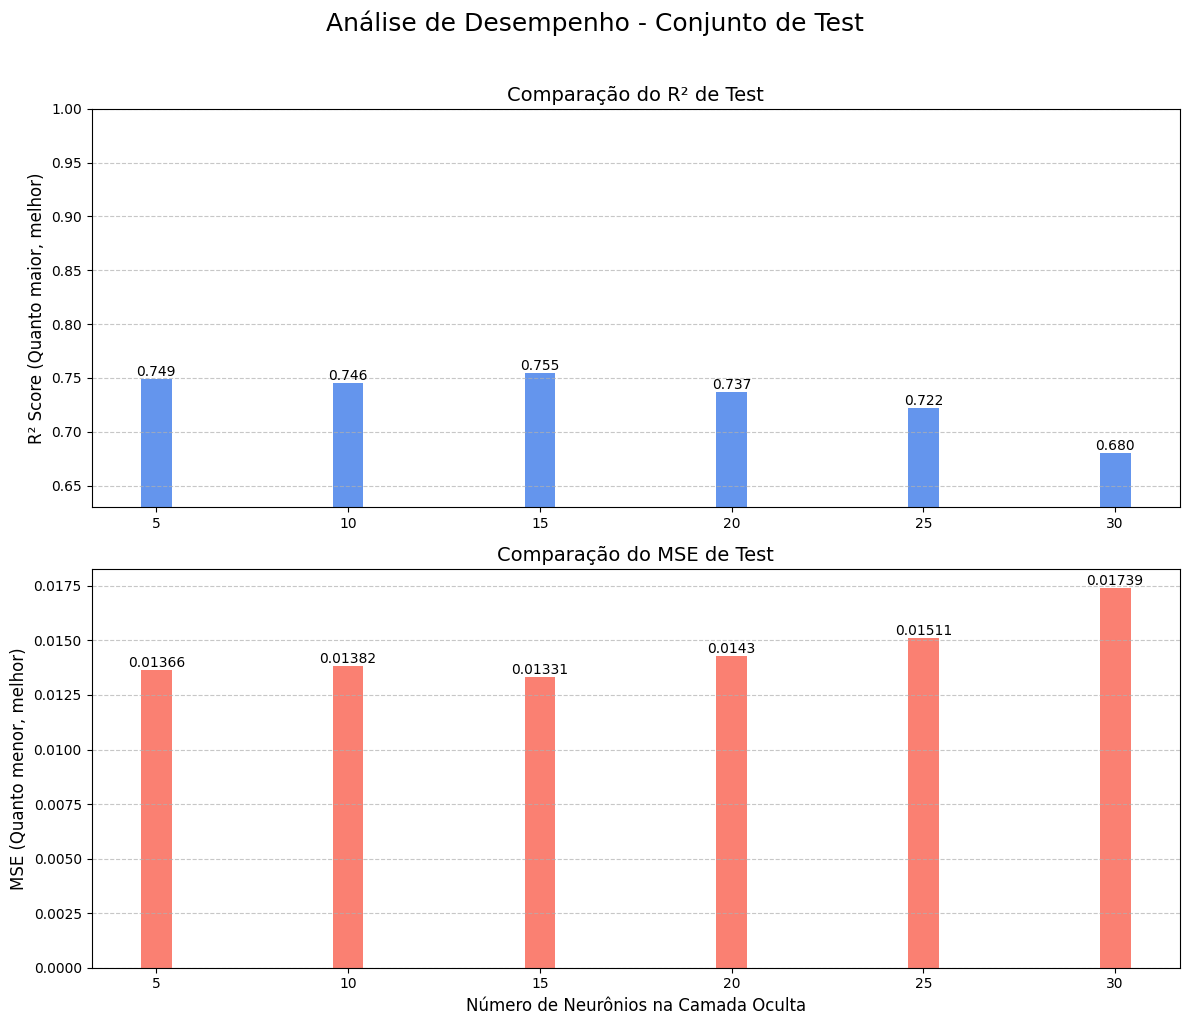

In [52]:
def print_metriscs(metrics):
    """
    Imprime as métricas de um modelo.
    """
    print("\nMétricas do modelo:")
    for split, m in metrics.items():
        print(f"\n{split} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4g}")

def plot_model_comparison(metrics_dict, data_split='Test'):
    """
    Cria gráficos de barras comparando o R2 e o MSE para um determinado
    conjunto de dados (Train, Validation ou Test).

    Args:
        metrics_dict (dict): Dicionário com os resultados dos modelos.
        data_split (str): O conjunto de dados a ser plotado. 
                          Valores válidos: 'Train', 'Validation', 'Test'.
                          O padrão é 'Test'.
    """
    try:
        # Extrai os dados para plotagem usando a chave 'data_split'
        units = list(metrics_dict.keys())
        r2_scores = [metrics[data_split]['R2'] for metrics in metrics_dict.values()]
        mse_scores = [metrics[data_split]['MSE'] for metrics in metrics_dict.values()]
    except KeyError:
        print(f"Erro: A chave '{data_split}' não foi encontrada nos dicionários de métricas.")
        print(f"Chaves disponíveis: {list(next(iter(metrics_dict.values())).keys())}")
        return

    # Cria a figura com dois subplots
    fig, axs = plt.subplots(2, 1, figsize=(12, 10))
    fig.suptitle(f'Análise de Desempenho - Conjunto de {data_split}', fontsize=18, y=1.02)

    # --- Gráfico 1: Comparação de R² ---
    bars_r2 = axs[0].bar(units, r2_scores, color='cornflowerblue')
    axs[0].set_title(f'Comparação do R² de {data_split}', fontsize=14)
    axs[0].set_ylabel('R² Score (Quanto maior, melhor)', fontsize=12)
    axs[0].set_xticks(units)
    axs[0].set_ylim(bottom=max(0, min(r2_scores) - 0.05), top=max(1.0, max(r2_scores) * 1.05))
    axs[0].grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars_r2:
        yval = bar.get_height()
        axs[0].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.3f}', ha='center', va='bottom', fontsize=10)

    # --- Gráfico 2: Comparação de MSE ---
    bars_mse = axs[1].bar(units, mse_scores, color='salmon')
    axs[1].set_title(f'Comparação do MSE de {data_split}', fontsize=14)
    axs[1].set_xlabel('Número de Neurônios na Camada Oculta', fontsize=12)
    axs[1].set_ylabel('MSE (Quanto menor, melhor)', fontsize=12)
    axs[1].set_xticks(units)
    axs[1].grid(axis='y', linestyle='--', alpha=0.7)
    for bar in bars_mse:
        yval = bar.get_height()
        axs[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4g}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

all_metrics = {
    5: metrics_5,
    10: metrics_10,
    15: metrics_15,
    20: metrics_20,
    25: metrics_25,
    30: metrics_30,
}

plot_model_comparison(all_metrics, data_split='Test')


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MSE entre Theta Original e Reconstruído: 1.424


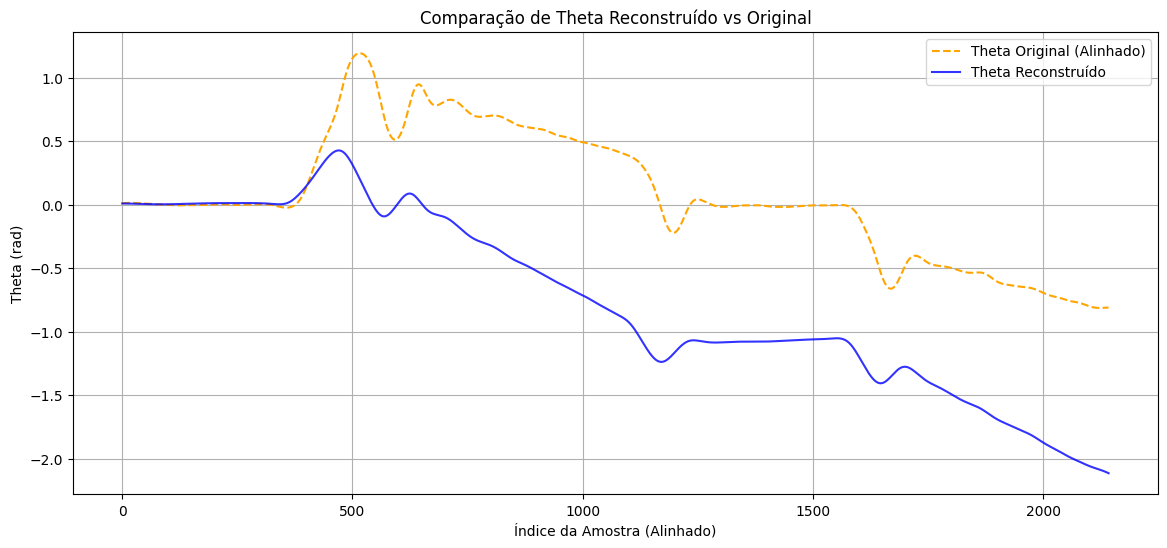

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
MSE entre Theta Original e Reconstruído: 0.696


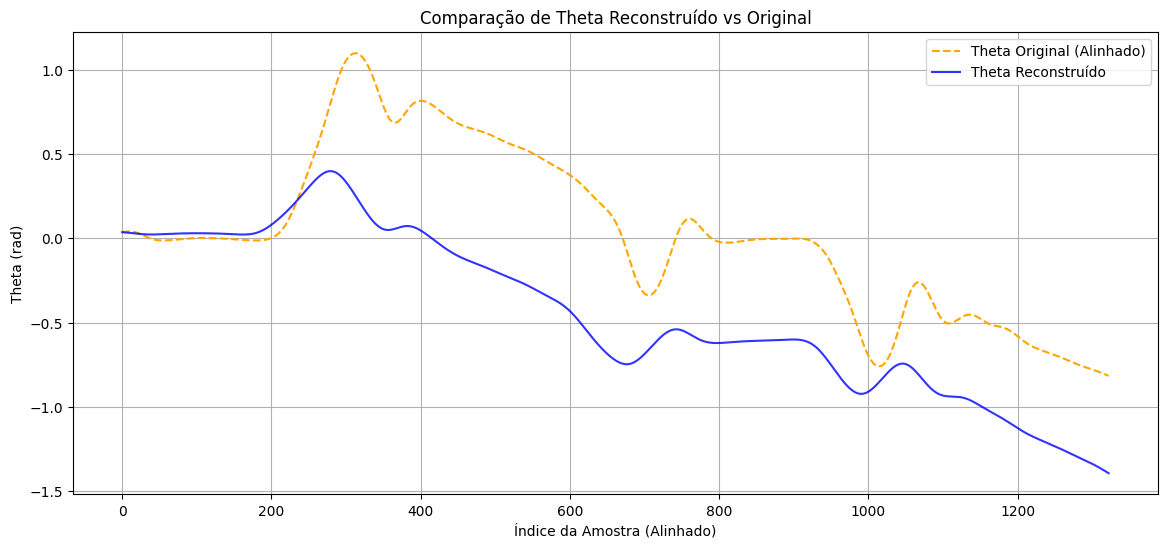

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MSE entre Theta Original e Reconstruído: 0.7257


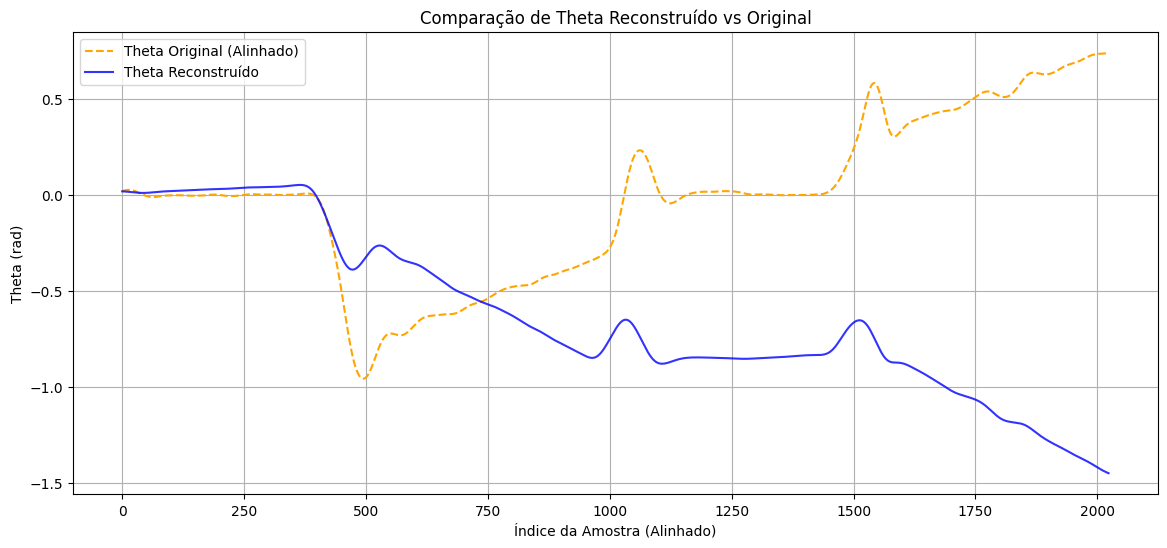

0.7256765168008664

In [21]:
Recontruir_Theta(model_15, train_x_seq, "./Dados/DataSmoothSpline1.csv", y_scaler)
Recontruir_Theta(model_15, x_val_seq, "./Dados/DataSmoothSpline2.csv", y_scaler)
Recontruir_Theta(model_15, x_test_seq, "./Dados/DataSmoothSpline3.csv", y_scaler)

Modelo 1:, unidades = 5, seed = 3845
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0, λ2=1
Epoch 1: Loss=0.009212, MSE_d=0.005726, MSE_f=0.009212, Val MSE=0.3871


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Early stopping na época 351
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Novo melhor modelo encontrado com MSE: 0.01973 e R2: 0.6369
Modelo 2:, unidades = 5, seed = 4876
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0, λ2=1
Epoch 1: Loss=0.008869, MSE_d=0.006575, MSE_f=0.008869, Val MSE=0.3058


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Early stopping na época 340
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Modelo 3:, unidades = 5, seed = 7034
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0, λ2=1
Epoch 1: Loss=0.01024, MSE_d=0.007821, MSE_f=0.01024, Val MSE=0.2553


...

Early stopping na época 329
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Modelo 9:, unidades = 20, seed = 6473
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0, λ2=1
Epoch 1: Loss=0.01316, MSE_d=0.0097, MSE_f=0.01316, Val MSE=0.2209


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Early stopping na época 329
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Modelo 10:, unidades = 20, seed = 6217
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0, λ2=1
Epoch 1: Loss=0.01224, MSE_d=0.01025, MSE_f=0.01224, Val MSE=0.1556


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Early stopping na época 317
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Melhor modelo final com MSE: 0.02484, R2 = 0.5427,unidades = 20, seed = 1532


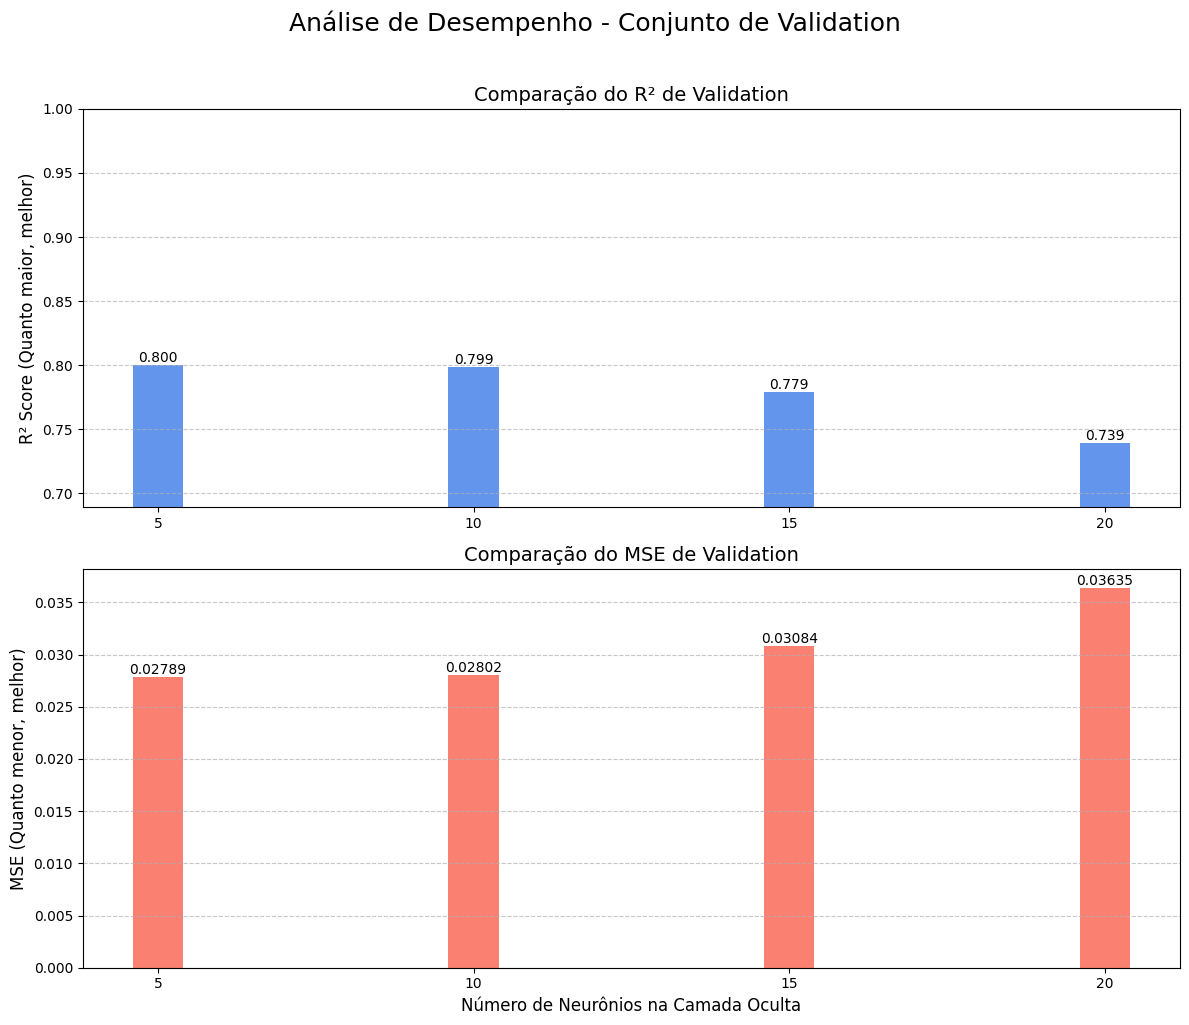

In [48]:
model_5_2, metrics_5_2 = Generate_Random_Models(units=5, lam_1= 0, lam_2=1)
model_10_2, metrics_10_2 = Generate_Random_Models(units=10, lam_1= 0, lam_2=1)
model_15_2, metrics_15_2 = Generate_Random_Models(units=15, lam_1= 0, lam_2=1)
model_20_2, metrics_20_2 = Generate_Random_Models(units=20, lam_1= 0, lam_2=1)

all_metrics_2 = {
    5: metrics_5_2,
    10: metrics_10_2,
    15: metrics_15_2,
    20: metrics_20_2,
}
plot_model_comparison(all_metrics_2, data_split='Test')



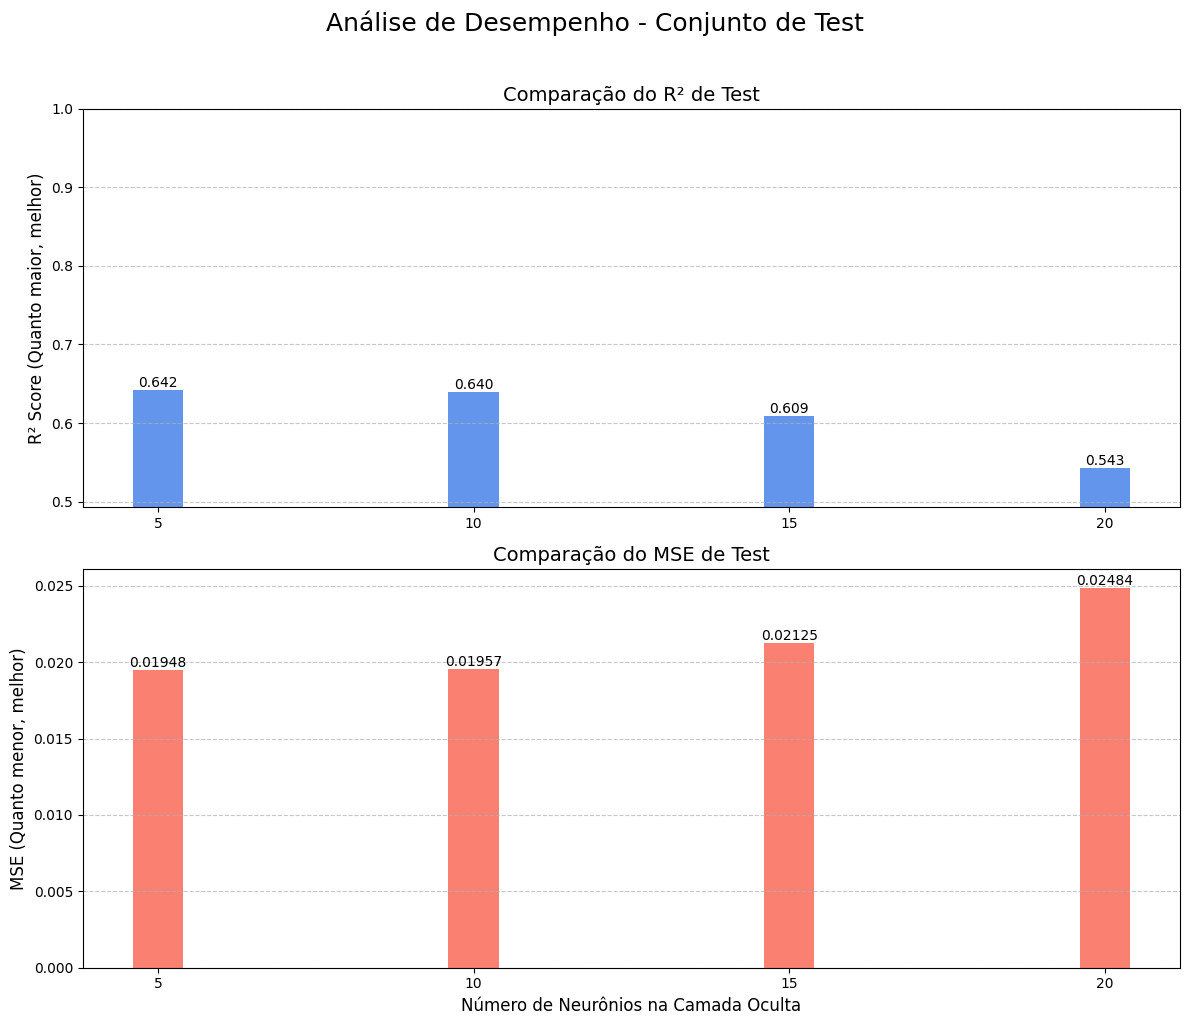

In [53]:
all_metrics_2 = {
    5: metrics_5_2,
    10: metrics_10_2,
    15: metrics_15_2,
    20: metrics_20_2,
}
plot_model_comparison(all_metrics_2, data_split='Test')

Modelo 1:, unidades = 4, seed = 6722
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1, λ2=0


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1: Loss=0.006269, MSE_d=0.006269, MSE_f=0.008682, Val MSE=0.8719
Early stopping na época 362
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Novo melhor modelo encontrado com MSE: 0.01296 e R2: 0.7615
Modelo 2:, unidades = 4, seed = 5991
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1, λ2=0
Epoch 1: Loss=0.006958, MSE_d=0.006958, MSE_f=0.00956, Val MSE=0.7785


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Early stopping na época 379
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Novo melhor modelo encontrado com MSE: 0.01284 e R2: 0.7636
Modelo 3:, unidades = 4, seed = 8124
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1, λ2=0
Epoch 1: Loss=0.007241, MSE_d=0.007241, MSE_f=0.009847, Val MSE=0.7141


...

Early stopping na época 315
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Novo melhor modelo encontrado com MSE: 0.01096 e R2: 0.7982
Modelo 9:, unidades = 8, seed = 5636
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1, λ2=0
Epoch 1: Loss=0.003486, MSE_d=0.003486, MSE_f=0.005718, Val MSE=0.5177


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Early stopping na época 341
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Modelo 10:, unidades = 8, seed = 9643
Treinando com Ts=0.07, L=0.123, R=0.034, λ1=1, λ2=0
Epoch 1: Loss=0.004338, MSE_d=0.004338, MSE_f=0.006814, Val MSE=0.4881


c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 500: Loss=0.003282, MSE_d=0.003282, MSE_f=0.005558, Val MSE=0.01598
Epoch 1000: Loss=0.003235, MSE_d=0.003235, MSE_f=0.005474, Val MSE=0.01581
Early stopping na época 1409
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Melhor modelo final com MSE: 0.01096, R2 = 0.7982,unidades = 8, seed = 8559


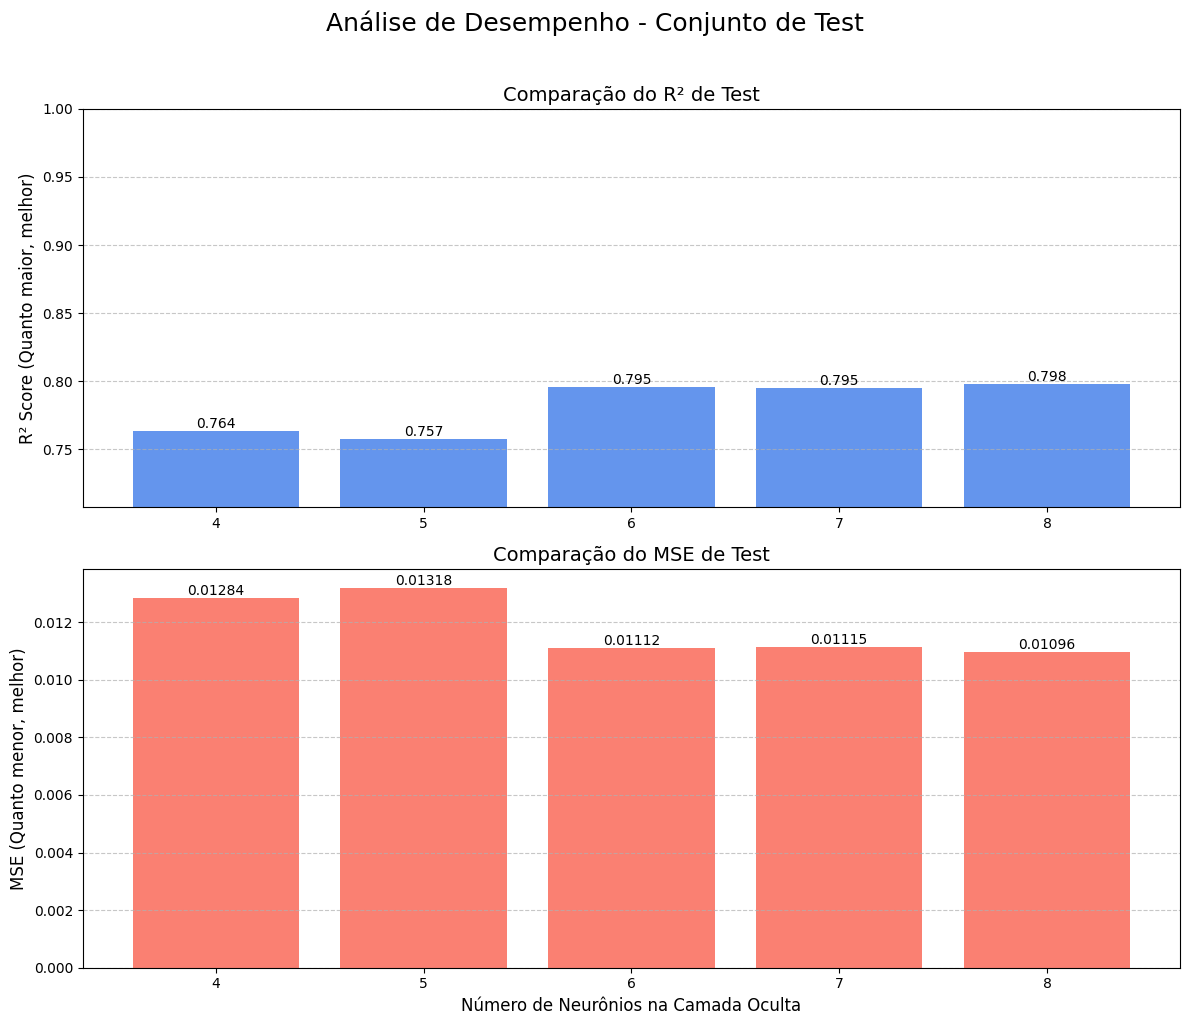

In [60]:
model_4_s, metrics_4_s = Generate_Random_Models(units=4, lam_1= 1, lam_2=0)
model_5_s, metrics_5_s = Generate_Random_Models(units=5, lam_1= 1, lam_2=0)
model_6_s, metrics_6_s = Generate_Random_Models(units=6, lam_1= 1, lam_2=0)
model_7_s, metrics_7_s = Generate_Random_Models(units=7, lam_1= 1, lam_2=0)
model_8_s, metrics_8_s = Generate_Random_Models(units=8, lam_1= 1, lam_2=0)
all_metrics_s = {
    4: metrics_4_s,
    5: metrics_5_s,
    6: metrics_6_s,
    7: metrics_7_s,
    8: metrics_8_s,
}

plot_model_comparison(all_metrics_s, data_split='Test')
